In [3]:
import sys
import argparse
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import numpy as np
import pandas as pd

import csv
import gzip

import scipy.io
import numpy as np 

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.pyplot import rc_context
import anndata
import torch

# --- MATPLOTLIB SETTINGS ---
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rc
rc_params = {
    "font.family": "sans-serif", # "text.usetex": True,
    "font.serif" : ['Arial'], # "font.size" : 6,
    "font.weight" : "normal",
    'xtick.labelsize' : 5,
    'ytick.labelsize' : 5,
    'legend.fontsize' : 5,
    'axes.labelsize' : 6,
    'axes.linewidth': 0.8,
    'lines.linewidth' : 1,
    'axes.titlesize' : 7, # figure.titlesize,
    'legend.title_fontsize' : 5
}
matplotlib.rcParams.update(rc_params)
margins = {  #     vvv margin in inches
    "left"   :     0.2,
    'right' : 1.0,
    'bottom' : 0.15
}

import helper_functions



In [4]:

# --- INIT ---



# which data to use
head_folder = "/".join(os.getcwd().split("/")[:3])
data_head_folder = '%s/Dropbox/aorta_circadian_data/datasets/joint' % head_folder
hvg_to_use = 'prior_knowledge_guided' # 'transformed_X_outlier_variance'
cluster_resolution = 0.05
subcluster_resolution = 0.20


# get corresponding paths
adata_path = '%s/adata_qc_filtered.h5ad' % data_head_folder
hvg_folder = '%s/data_annotations/hvg/%s' % (data_head_folder,hvg_to_use)
scvi_res_folder = '%s/scvi_res' % hvg_folder
scvi_mean_embedding_df_path = '%s/scvi_mean_embedding.tsv' % scvi_res_folder
umap_path_out = '%s/scvi_mean_umap_embedding.tsv' % scvi_res_folder

# clusters
clustering_folder = '%s/clustering/res_%s' % (scvi_res_folder, str(cluster_resolution))
cluster_df_fileout = '%s/clusters.tsv' % (clustering_folder)

# SMC clusters
subclustering_folder = '%s/subclustering/res_%s' % (clustering_folder,subcluster_resolution)
subcluster_df_fileout = '%s/smc_subclusters.tsv' % (subclustering_folder)


# settings
use_subclusters = False


# set the cluster column
if use_subclusters:
    clustering_folder = subclustering_folder
    cluster_df_fileout = subcluster_df_fileout



In [5]:
# --- GET UNIQUE CLUSTERS ---


descriptions = ['male aligned bmal1-control',
    'male aligned bmal1-ko',
    'male misaligned bmal1-control',
    'female aligned bmal1-control',
    'female aligned bmal1-ko',
    'female misaligned bmal1-control',
    ]
description_loc_list = [[0,0], [0,1], [0,2], [1,0], [1,1], [1,2]]

try:
    clusters = sorted(list(pd.read_table(cluster_df_fileout,index_col=None)['leiden_scvi_cluster'].unique()))
except:
    clusters = sorted(list(pd.read_table(cluster_df_fileout,index_col=None)['smc_subcluster'].unique()))
clusters = list(filter(lambda x: ~np.isnan(x),clusters)) # get rid of NaN cluster (only relevant for SMC subcluster)
clusters = list(map(lambda x: int(x),clusters))
clusters



[0, 1, 2, 3, 4, 5, 6, 7, 8]

In [6]:
# --- LOAD THE ADATA ---

import anndata
adata = anndata.read_h5ad(adata_path)

adata



AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'

In [7]:
# --- ADD EMBEDDINGS TO ADATA ---



# ** load embeddings and clusters **
scvi_mean_embedding_df = pd.read_table(scvi_mean_embedding_df_path,sep='\t',index_col='barcode')
umap_embedding_df = pd.read_table(umap_path_out,sep='\t',index_col='barcode')
cluster_df = pd.read_table(cluster_df_fileout,sep='\t',index_col='index')
subcluster_df = pd.read_table(subcluster_df_fileout,sep='\t',index_col='index')


# ** make sure everything in the same order
adata = adata[list(scvi_mean_embedding_df.index)]
umap_umap_embedding_df = umap_embedding_df.loc[list(scvi_mean_embedding_df.index)]
cluster_df = cluster_df.loc[list(scvi_mean_embedding_df.index)]
subcluster_df = subcluster_df.loc[list(scvi_mean_embedding_df.index)]


# ** add embeddings **
adata.obsm["X_scVI"] = np.array(scvi_mean_embedding_df)
adata.obsm["X_scVI_umap"] = np.array(umap_embedding_df)
if use_subclusters:
    adata.obs["cluster"] = np.array(cluster_df['smc_subcluster'])
else:
    adata.obs["cluster"] = np.array(cluster_df['leiden_scvi_cluster'])
adata



AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description', 'cluster'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'
    obsm: 'X_scVI', 'X_scVI_umap'

In [8]:
# --- SET THE CLUSTER ---

cluster = 0



In [9]:
# --- GET THE CLUSTER ADATA ---

cluster_adata = adata[adata.obs['cluster'] == cluster]
cluster_adata


View of AnnData object with n_obs × n_vars = 116054 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description', 'cluster'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'
    obsm: 'X_scVI', 'X_scVI_umap'

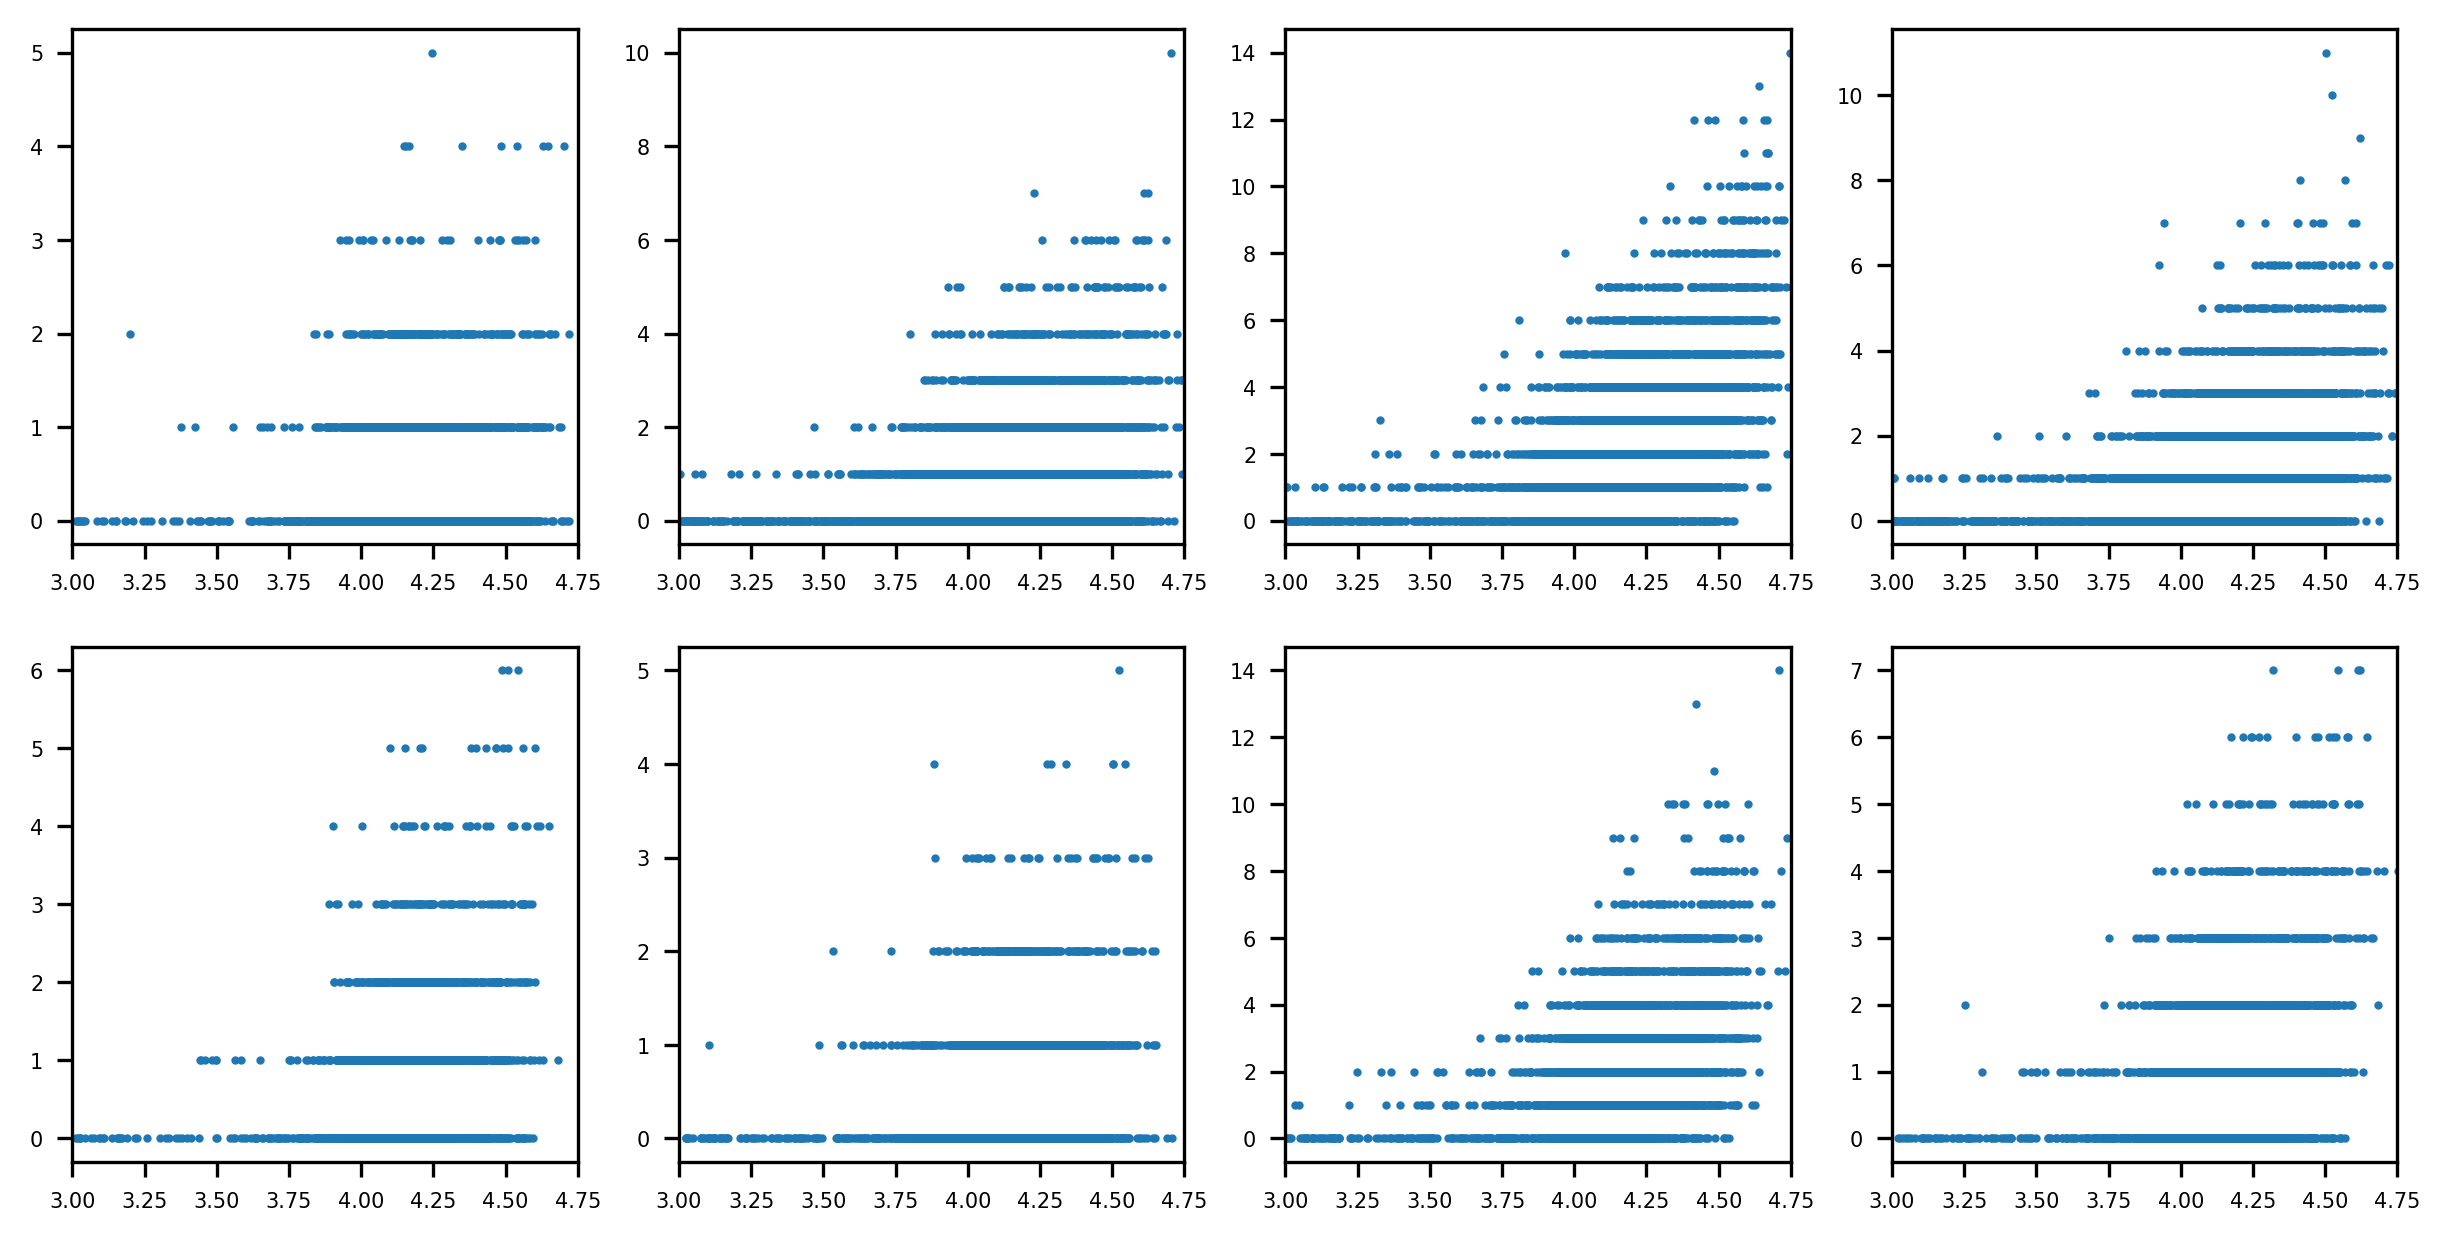

In [32]:
# --- LOOK BMAL1 AND DBP EXPRESSION AT THE 4 TIME POINTS ---

gene = 'Tef'

fig,axs=plt.subplots(figsize=(10,5),nrows=2,ncols=4,dpi=300)
for condit_index, condition in enumerate(['male aligned bmal1-control','male misaligned bmal1-control']):
    sub_adata = cluster_adata[cluster_adata.obs['description'] == condition]
    for zt_index, zt in enumerate([0,6,12,18]):
        zt_sub_adata = sub_adata[sub_adata.obs['zt'] == zt]
        axs[condit_index,zt_index].scatter(np.log10(zt_sub_adata.obs['lib_size']),np.array(zt_sub_adata[:,gene].X.todense()).flatten(),s=1)
        axs[condit_index,zt_index].set_xlim((3,4.75))




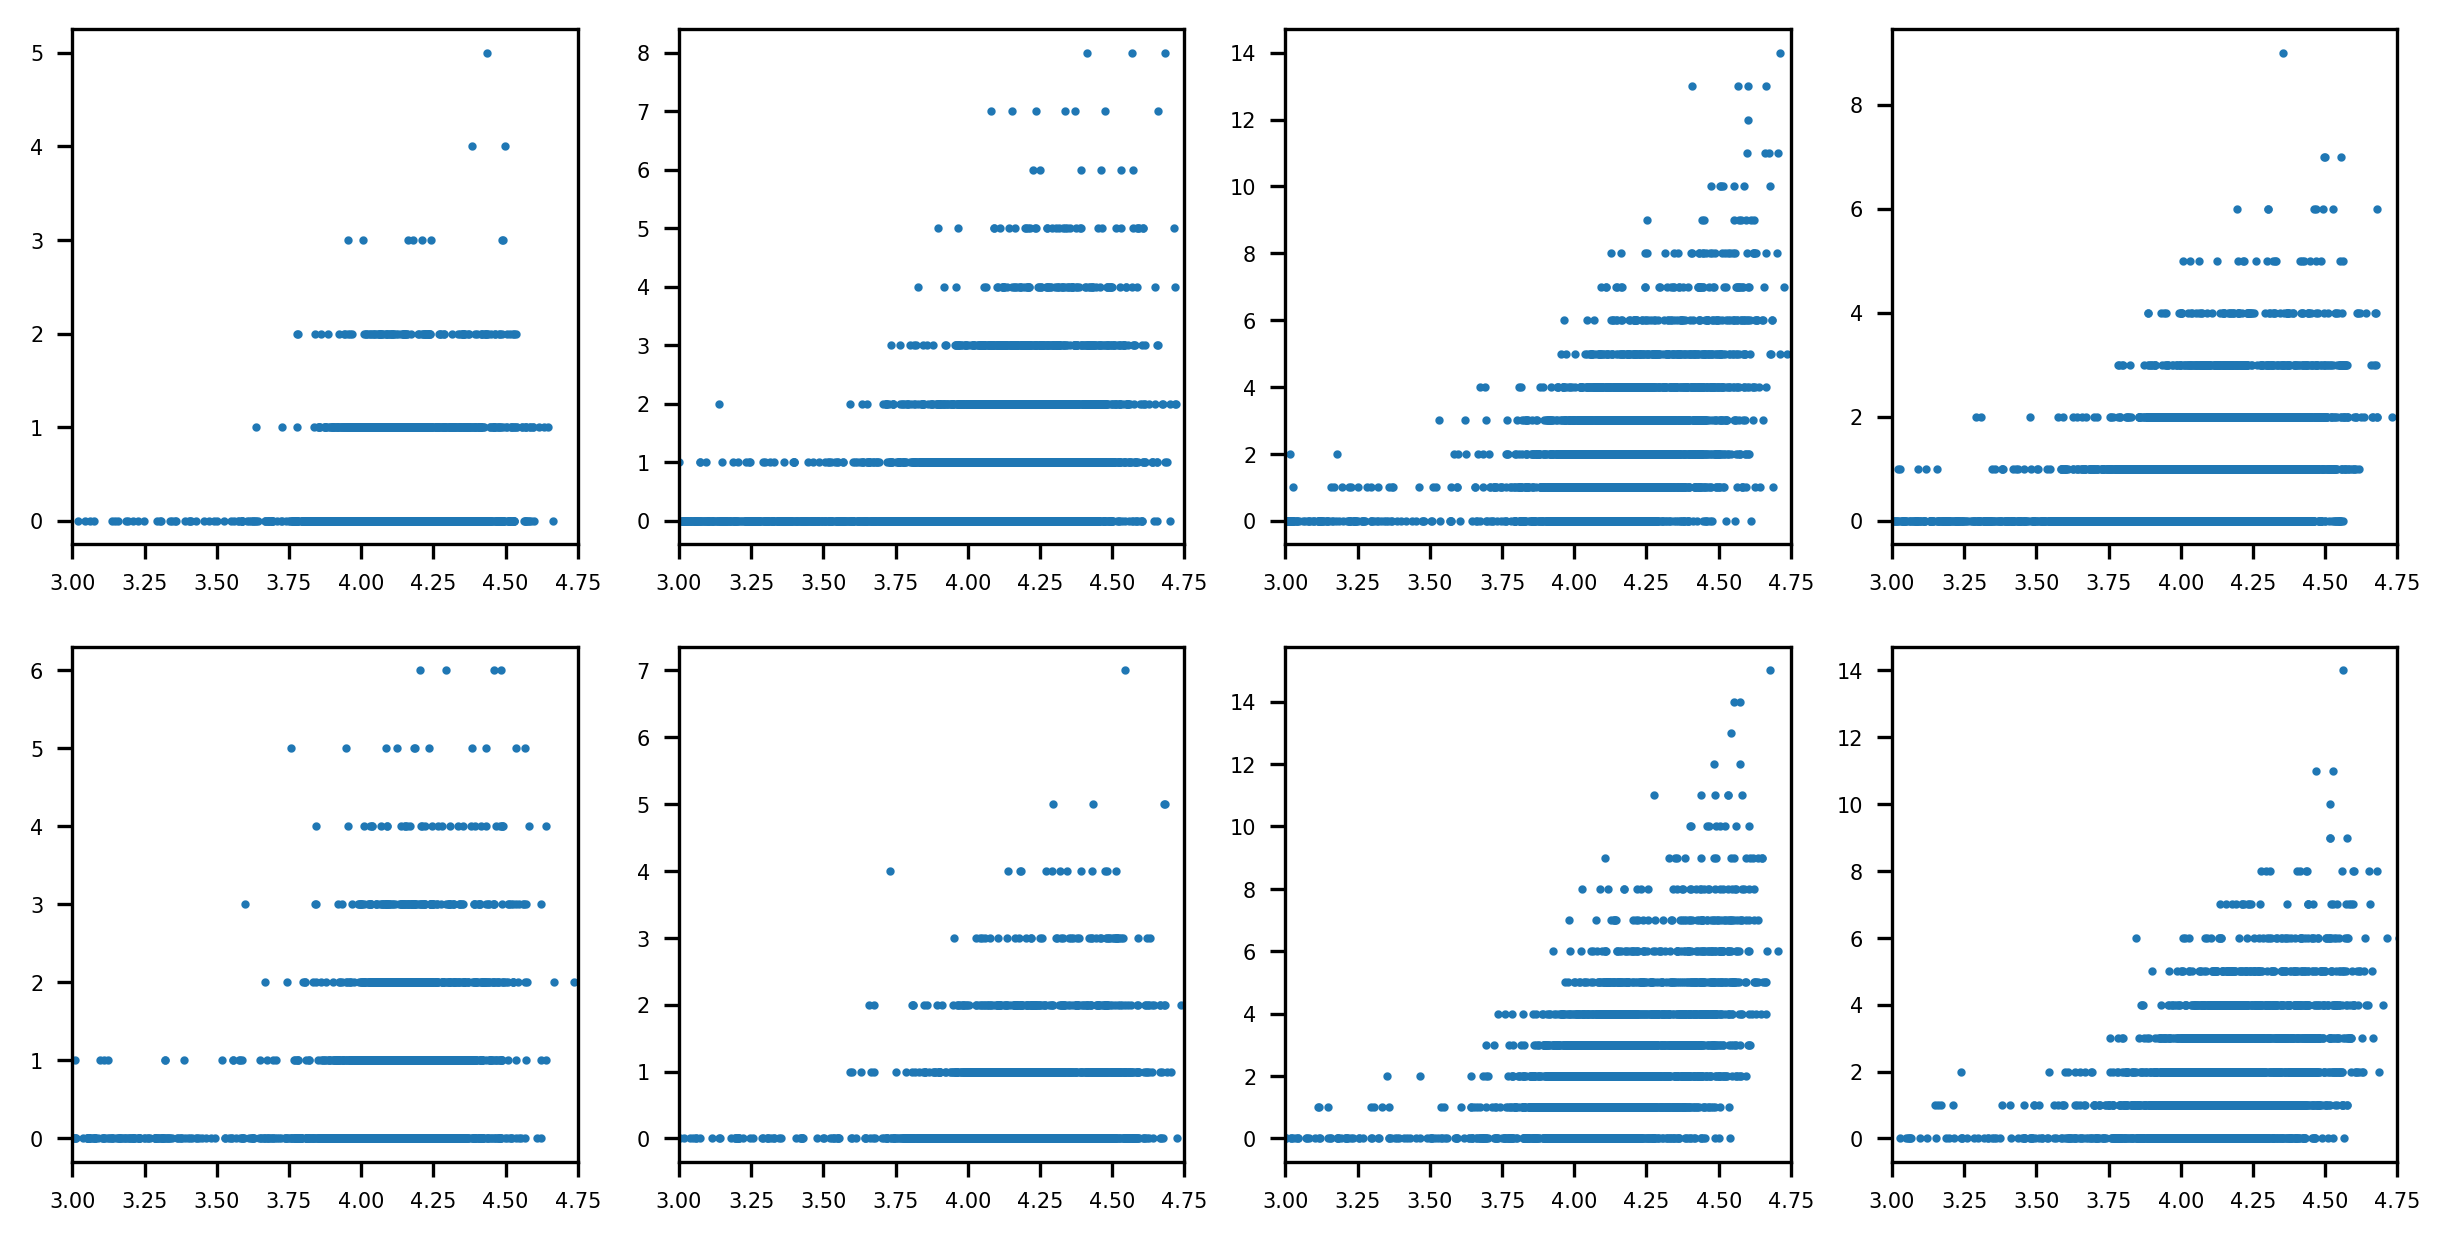

In [33]:
# --- LOOK BMAL1 AND DBP EXPRESSION AT THE 4 TIME POINTS ---

gene = 'Tef'

fig,axs=plt.subplots(figsize=(10,5),nrows=2,ncols=4,dpi=300)
for condit_index, condition in enumerate(['female aligned bmal1-control','female misaligned bmal1-control']):
    sub_adata = cluster_adata[cluster_adata.obs['description'] == condition]
    for zt_index, zt in enumerate([0,6,12,18]):
        zt_sub_adata = sub_adata[sub_adata.obs['zt'] == zt]
        axs[condit_index,zt_index].scatter(np.log10(zt_sub_adata.obs['lib_size']),np.array(zt_sub_adata[:,gene].X.todense()).flatten(),s=1)
        axs[condit_index,zt_index].set_xlim((3,4.75))




